# 중고거래 상품 데이터 전처리 및 탐색 분석

## tl;dr

- 중복 제거 후 통합 데이터는 **11,550건**, 중고나라 데이터는 **3,561건**입니다.
- 중고나라 3,561건은 모두 통합 데이터에 포함되어 있으므로 두 파일을 단순 결합하면 중복 집계됩니다.
- 분석 기준 파일은 `market_products_analysis_dataset.csv`이며, 기준 당근 파일과 같은 21개 컬럼에 분석용 `플랫폼` 컬럼을 추가했습니다.
- 가격 중앙값은 통합 데이터 **79,000원**, 중고나라 **90,000원**입니다. 다만 부품 및 가격 불확실 행을 제외한 비교는 아래 셀에서 별도로 확인합니다.
- 지역의 `구`를 확정하지 못한 비율은 통합 49.32%, 중고나라 97.08%여서 구 단위 분석은 `미상`을 분리해야 합니다.


## Context & Methods

### Key Assumptions

- 한 행은 하나의 판매 게시물입니다.
- 기준 당근 CSV와 15개 원천 컬럼이 정확히 같은 행은 기준 파일의 파생값을 재사용했습니다.
- 나머지 행은 제목·설명·지역의 키워드로 `구`, `완제품여부`, `세부유형`을 보완했습니다.
- 가격 분석은 원화 정수형 `가격원`을 사용하며, `완제품여부=완제품` 및 `가격신뢰=신뢰`를 기본 유효 표본으로 봅니다.
- 결과는 기술·탐색 분석이며 인과관계를 뜻하지 않습니다.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ANALYSIS_DIR = Path.cwd()
OUTPUT_DIR = ANALYSIS_DIR / "output"
DATA_PATH = OUTPUT_DIR / "market_products_analysis_dataset.csv"
SUMMARY_PATH = OUTPUT_DIR / "quality_summary.json"

pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid", font_scale=0.95)
data = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
summary = json.loads(SUMMARY_PATH.read_text(encoding="utf-8"))
data.shape, data.head(3)

mkdir -p failed for path C:\Users\concr\AppData\Local\matplotlib: [WinError 5] 액세스가 거부되었습니다: 'C:\\Users\\concr\\AppData\\Local\\matplotlib'


Matplotlib created a temporary cache directory at C:\Users\Public\Documents\ESTsoft\CreatorTemp\matplotlib-tn_85yn8 because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


((11550, 22),
      플랫폼     구 카테고리      검색어               제목   상태       가격     지역  \
 0  당근/기타  영등포구  청소기  다이슨 청소기  다이슨 청소기 충전기+거치대  거래중  20,000원   여의도동   
 1  당근/기타  영등포구  청소기  다이슨 청소기      다이슨 청소기 장난감  예약중  10,000원  양평제1동   
 2  당근/기타  영등포구  청소기  다이슨 청소기    다이슨 V6 무선 청소기  거래중  15,000원  당산제1동   
 
          등록시각  채팅수  관심수  조회수  매너온도   판매자닉네임 상세카테고리               거래희망장소  \
 0  2026-08-09    1    6  969   NaN  gotojfk   생활가전  9호선 양천향교역 인근 직거래합니다   
 1  2026-08-30    0    0    8   NaN     더당그너    유아동     직거래는 평일 8시 이후 가능   
 2  2026-08-30    1    1  212   NaN      백프로   생활가전                  직거래   
 
                                                 상세설명    가격원 완제품여부 세부유형  가격신뢰  \
 0  다이슨 무선 청소기 충전기와 거치대입니다.\n국내 정발 220v 버전입니다\n\n9...  20000   완제품   일반    신뢰   
 1  아이들이 좋아하는 다이슨 청소기 장난감이에요\n실제 청소기처럼 작동하는 재미있는 장...  10000    부품   일반  해당없음   
 2  다이슨 V6 무선 청소기 판매해요\n사진에 보이는 구성품 그대로 드려요\n깔끔한 디...  15000   완제품   V6    신뢰   
 
   날짜정밀도  
 0    정밀  
 1    정밀  
 2    정밀  )

## Data

### 1. 스키마와 품질 요약

In [2]:
quality = pd.DataFrame(summary["quality"])
quality[[
    "dataset", "input_rows", "output_rows", "exact_duplicates_removed",
    "reference_matches", "reference_match_rate_pct", "district_unknown_rate_pct",
    "price_missing", "price_median_won", "component_rows", "approximate_date_rows"
]]

,dataset,input_rows,output_rows,exact_duplicates_removed,reference_matches,reference_match_rate_pct,district_unknown_rate_pct,price_missing,price_median_won,component_rows,approximate_date_rows
0,integrated_market_products,11681,11550,131,4586,39.71,49.32,0,79000,959,2703
1,joonggonara,3692,3561,131,0,0.00,97.08,0,90000,83,0


In [3]:
required_columns = [
    "플랫폼", "구", "카테고리", "검색어", "제목", "상태", "가격", "지역", "등록시각",
    "채팅수", "관심수", "조회수", "매너온도", "판매자닉네임", "상세카테고리",
    "거래희망장소", "상세설명", "가격원", "완제품여부", "세부유형", "가격신뢰", "날짜정밀도"
]
assert list(data.columns) == required_columns
assert data.duplicated(subset=required_columns[2:17]).sum() == 0
assert set(data["가격신뢰"].dropna().unique()) <= {"신뢰", "불확실", "해당없음"}
assert set(data["완제품여부"].dropna().unique()) <= {"완제품", "부품"}
print("스키마·중복·분류값 검증 통과")

스키마·중복·분류값 검증 통과


## Results

### 2. 플랫폼 구성과 가격 분포

In [4]:
platform_counts = data["플랫폼"].value_counts().rename_axis("플랫폼").reset_index(name="게시물수")
valid_price = data[
    data["가격원"].notna()
    & data["가격신뢰"].eq("신뢰")
    & data["완제품여부"].eq("완제품")
].copy()
platform_price = (
    valid_price.groupby("플랫폼")["가격원"]
    .agg(표본수="size", 중앙값="median", 평균="mean", 하위25="quantile")
)
platform_price["하위25"] = valid_price.groupby("플랫폼")["가격원"].quantile(0.25)
platform_price["상위75"] = valid_price.groupby("플랫폼")["가격원"].quantile(0.75)
platform_counts, platform_price.round(0).astype(int)

(     플랫폼  게시물수
 0  당근/기타  5445
 1   중고나라  3561
 2   번개장터  2544,
         표본수    중앙값      평균   하위25    상위75
 플랫폼                                      
 당근/기타  4595  76000  117868  30000  180000
 번개장터   2487  90000  135220  50000  180000
 중고나라   3478  90000  140015  40000  182250)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_64204\919823980.py:11: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_64204\919823980.py:11: UserWarning: Glyph 44540 (\N{HANGUL SYLLABLE GEUN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_64204\919823980.py:11: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_64204\919823980.py:11: UserWarning: Glyph 53440 (\N{HANGUL SYLLABLE TA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_64204\919823980.py:11: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_64204\919823980.py:11: UserWarning: Glyph 44256 

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_64204\919823980.py:11: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_64204\919823980.py:11: UserWarning: Glyph 54952 (\N{HANGUL SYLLABLE HYO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_64204\919823980.py:11: UserWarning: Glyph 50756 (\N{HANGUL SYLLABLE WAN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_64204\919823980.py:11: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_64204\919823980.py:11: UserWarning: Glyph 54408 (\N{HANGUL SYLLABLE PUM}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_64204\919823980.py:11: UserWarning: Glyph 44032 (\N

C:\Users\concr\final\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\concr\final\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\concr\final\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 54952 (\N{HANGUL SYLLABLE HYO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\concr\final\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 50756 (\N{HANGUL SYLLABLE WAN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\concr\final\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\co

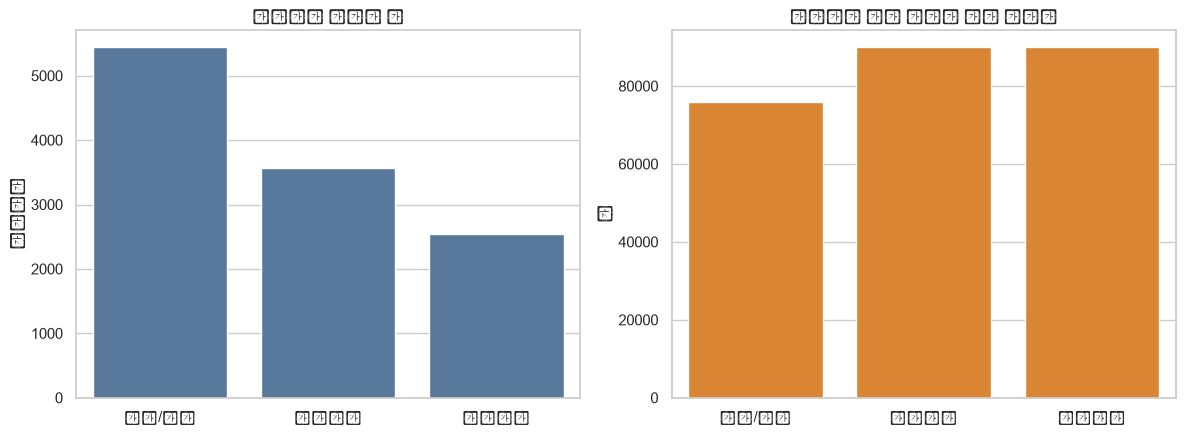

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(data=platform_counts, x="플랫폼", y="게시물수", ax=axes[0], color="#4C78A8")
axes[0].set_title("플랫폼별 게시물 수")
axes[0].set_xlabel("")

price_plot = platform_price.reset_index()
sns.barplot(data=price_plot, x="플랫폼", y="중앙값", ax=axes[1], color="#F58518")
axes[1].set_title("플랫폼별 유효 완제품 가격 중앙값")
axes[1].set_xlabel("")
axes[1].set_ylabel("원")
plt.tight_layout()
plt.show()

### 3. 카테고리별 규모와 가격

In [6]:
category_summary = (
    valid_price.groupby("카테고리")
    .agg(게시물수=("가격원", "size"), 가격중앙값=("가격원", "median"), 가격평균=("가격원", "mean"))
    .sort_values("게시물수", ascending=False)
)
category_summary.round(0).astype(int)

,게시물수,가격중앙값,가격평균
카테고리,,,
밥솥,3266,50000,84287
청소기,2677,50000,128192
마미케어,2638,150000,157208
전자기기,866,70000,86260
음식물처리기,787,300000,282731
분유포트,326,80000,105804


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_64204\1818826610.py:8: UserWarning: Glyph 44172 (\N{HANGUL SYLLABLE GE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_64204\1818826610.py:8: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_64204\1818826610.py:8: UserWarning: Glyph 47932 (\N{HANGUL SYLLABLE MUL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_64204\1818826610.py:8: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_64204\1818826610.py:8: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_64204\1818826610.py:8: UserWarning: Glyph 50976 (\N{

C:\Users\concr\final\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 44172 (\N{HANGUL SYLLABLE GE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\concr\final\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\concr\final\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 47932 (\N{HANGUL SYLLABLE MUL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\concr\final\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\concr\final\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\conc

C:\Users\concr\final\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\concr\final\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\concr\final\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\concr\final\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\concr\final\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 50521 (\N{HANGUL SYLLABLE ANG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\User

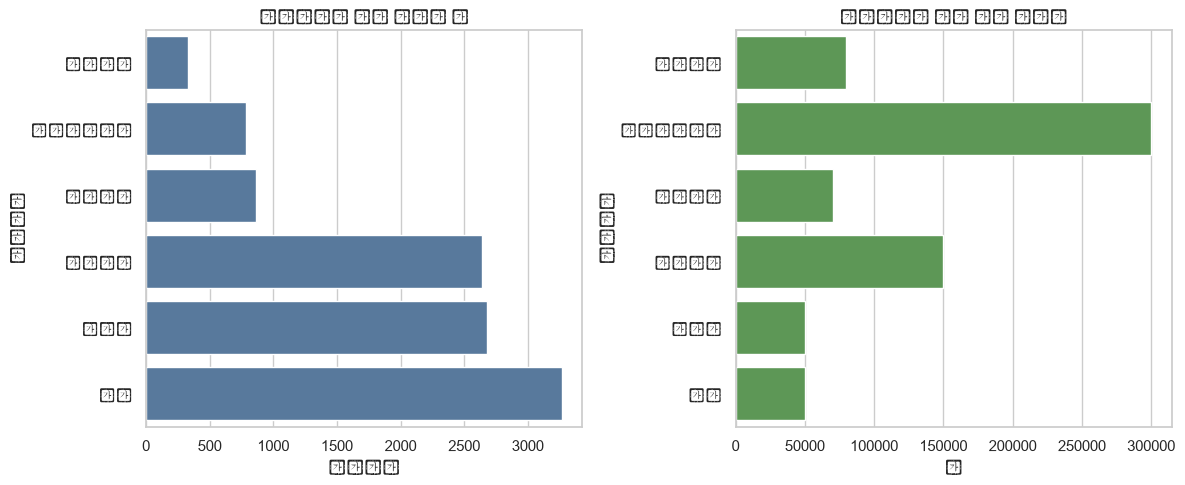

In [7]:
plot_data = category_summary.reset_index().sort_values("게시물수", ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=plot_data, y="카테고리", x="게시물수", ax=axes[0], color="#4C78A8")
axes[0].set_title("카테고리별 유효 게시물 수")
sns.barplot(data=plot_data, y="카테고리", x="가격중앙값", ax=axes[1], color="#54A24B")
axes[1].set_title("카테고리별 유효 가격 중앙값")
axes[1].set_xlabel("원")
plt.tight_layout()
plt.show()

### 4. 거래 상태와 참여 지표

In [8]:
status_share = pd.crosstab(data["플랫폼"], data["상태"], normalize="index").mul(100).round(1)
engagement_corr = data[["가격원", "채팅수", "관심수", "조회수"]].corr(method="spearman").round(3)
display(status_share)
display(engagement_corr)

상태,거래완료,거래중,나눔완료,예약중
플랫폼,,,,
당근/기타,72.2,20.8,4.2,2.7
번개장터,25.3,62.1,0.0,12.5
중고나라,67.4,30.5,0.0,2.1


,가격원,채팅수,관심수,조회수
가격원,1.000,-0.153,0.061,-0.135
채팅수,-0.153,1.000,0.562,0.877
관심수,0.061,0.562,1.000,0.627
조회수,-0.135,0.877,0.627,1.000


## Takeaways

- 통합 파일이 이미 중고나라 파일 전체를 포함하므로 전체 시장 분석은 통합 파일만 사용해야 합니다.
- 가격 비교에서는 부품과 가격 불확실 행을 제외하고 중앙값과 사분위 범위를 함께 보세요. 평균은 고가 이상치에 민감합니다.
- 중고나라 행은 구 정보가 대부분 확정되지 않으므로 구별 비교 결과에 포함시키면 지역 편향이 생길 수 있습니다.
- 플랫폼별 채팅·관심·조회 지표는 수집 정책이 서로 다를 수 있어 절대값 비교보다 플랫폼 내부 순위나 상관관계 분석에 적합합니다.
- 다음 분석 단계로는 동일 카테고리·세부유형 내 플랫폼 가격 차이, 판매상태별 가격 차이, 조회 대비 관심/채팅 전환율을 권장합니다.
